In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("data/movie_data_encoded.csv")

In [45]:
def error_analysis(y_true, y_pred, X_data):
    residuals = y_true - y_pred
    error_df = X_data.assign(
        true_revenue=y_true / 1e6,
        pred_revenue=y_pred / 1e6,
        residual=residuals / 1e6,
        pct_error=residuals / y_true
    )

    # Top 5 underestimations (model predicted too low)
    print("Top 5 Underestimations:")
    top_underestimates = error_df.nlargest(5, 'residual')
    display(top_underestimates)

    # Top 5 overestimations (model predicted too high)
    print("\nTop 5 Overestimations:")
    top_overestimates = error_df.nsmallest(5, 'residual')
    display(top_overestimates)

    return error_df, top_underestimates, top_overestimates

def plot_residual_diagnostics(y_true, y_pred):
    residuals = y_true - y_pred
    standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # Residuals vs Fitted
    axs[0, 0].scatter(y_pred, residuals, alpha=0.6)
    axs[0, 0].axhline(0, color='red', linestyle='--')
    axs[0, 0].set_title('Residuals vs Fitted')
    axs[0, 0].set_xlabel('Fitted Values')
    axs[0, 0].set_ylabel('Residuals')

    # Q-Q Plot
    stats.probplot(residuals, dist="norm", plot=axs[0, 1])
    axs[0, 1].set_title('Normal Q-Q Plot')

    # Histogram of Residuals
    sns.histplot(residuals, bins=30, kde=True, ax=axs[1, 0])
    axs[1, 0].set_title('Histogram of Residuals')

    # Residuals vs Order
    axs[1, 1].plot(residuals, marker='o', linestyle='', alpha=0.6)
    axs[1, 1].axhline(0, color='red', linestyle='--')
    axs[1, 1].set_title('Residuals vs Observation Order')
    axs[1, 1].set_xlabel('Observation Order')
    axs[1, 1].set_ylabel('Residual')

    plt.tight_layout()
    plt.show()

def handle_outliers(df, columns, method='cap'):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.05)
        Q3 = df_clean[col].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR

        if method == 'cap':
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
    return df_clean

In [5]:
df.columns

Index(['Unnamed: 0', 'name', 'genres', 'directors', 'writers', 'averageRating',
       'numVotes', 'actors', 'original_language', 'production_companies',
       'release_date', 'budget', 'revenue', 'runtime', 'status', 'keywords',
       'trailer_views', 'trailer_likes', 'titleType_movie',
       'titleType_tvMovie', 'director_score', 'writer_score', 'actor_score',
       'star_score', 'is_documentary', 'genres_Action', 'genres_Adult',
       'genres_Adventure', 'genres_Animation', 'genres_Biography',
       'genres_Comedy', 'genres_Crime', 'genres_Documentary', 'genres_Drama',
       'genres_Family', 'genres_Fantasy', 'genres_Film-Noir', 'genres_History',
       'genres_Horror', 'genres_Music', 'genres_Musical', 'genres_Mystery',
       'genres_Romance', 'genres_Sci-Fi', 'genres_Sport', 'genres_Thriller',
       'genres_War', 'genres_Western', 'is_holiday_release',
       'is_competitive_month', 'production_popular', 'lang_en', 'lang_fr',
       'lang_es', 'lang_hi', 'lang_ja', 'lang_

In [56]:
df_clean = df[(df['trailer_views'] >= 0) & (df['trailer_likes'] >= 0)].copy()
df_clean = handle_outliers(df_clean, df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist())

df_clean['release_year'] = pd.to_datetime(df_clean['release_date']).dt.year
df_clean['release_year_centered'] = df_clean['release_year'] - df_clean['release_year'].mean()

important_feature_based_on_domain_expertise = ['budget', 'actor_score', 'star_score', 'is_holiday_release', 'averageRating', 'trailer_views', 'trailer_likes', 'revenue', 'production_popular', 
                                               'release_year_centered']
test = df_clean[important_feature_based_on_domain_expertise].copy()

test['revenue'] = np.log1p(test['revenue'])
test['trailer_likes_log'] = np.log1p(test['trailer_likes'])
test['trailer_views_log'] = np.log1p(test['trailer_views'])
test['budget_log'] = np.log1p(test['budget'])
test['actor_score_log'] = np.log1p(test['actor_score'])
test['star_score_log'] = np.log1p(test['star_score'])
test['budget_actor_interaction'] = test['budget_log'] * test['actor_score_log']
test['trailer_star_interaction'] = test['trailer_likes_log'] * test['star_score_log']
test['star_actor_interaction'] = test['star_score_log'] * test['actor_score_log']


In [62]:
df_clean['release_year'].describe()

count    10487.000000
mean      2001.056355
std         18.332679
min       1914.000000
25%       1993.000000
50%       2006.000000
75%       2014.000000
max       2023.000000
Name: release_year, dtype: float64

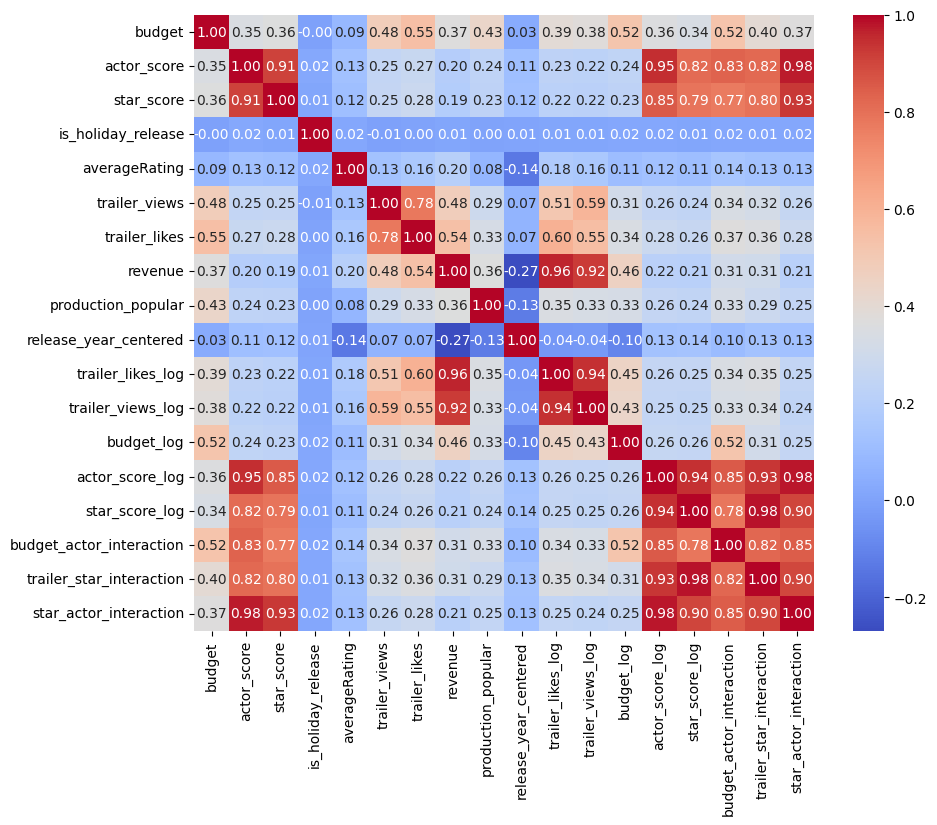

In [57]:
# Calculate the correlation matrix
corr_matrix = test.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [58]:
test.shape

(10487, 18)

In [69]:
X = test[['trailer_views_log', 'trailer_likes_log', 'budget_log', 'budget_actor_interaction', 'release_year_centered']]
y = df_clean['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = np.log1p(y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")

Mean Squared Error: 15.86 Millions
R-squared: 0.82


In [79]:
EL_tune = ElasticNet()

search_space = {
    'alpha': np.logspace(-4, 2, 50),  # Regularization strength (L1 + L2)
    'l1_ratio': np.linspace(0, 1, 21),  # Balance between L1 (lasso) and L2 (ridge)
}

grid_search = GridSearchCV(
    estimator=EL_tune,
    param_grid=search_space,
    cv=KFold(n_splits=5),
    scoring='neg_mean_squared_error',
    n_jobs=-1  # Optional: speeds things up if you have multiple cores
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=ElasticNet(), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-04, 1.32571137e-04, 1.75751062e-04, 2.32995181e-04,
       3.08884360e-04, 4.09491506e-04, 5.42867544e-04, 7.19685673e-04,
       9.54095476e-04, 1.26485522e-03, 1.67683294e-03, 2.22299648e-03,
       2.94705170e-03, 3.90693994e-03, 5.17947468e-03...
       2.55954792e+00, 3.39322177e+00, 4.49843267e+00, 5.96362332e+00,
       7.90604321e+00, 1.04811313e+01, 1.38949549e+01, 1.84206997e+01,
       2.44205309e+01, 3.23745754e+01, 4.29193426e+01, 5.68986603e+01,
       7.54312006e+01, 1.00000000e+02]),
                         'l1_ratio': array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])},
             scoring='neg_mean_squared_error')

In [80]:
model = ElasticNet(alpha=np.float64(0.006866488450042998), l1_ratio=np.float64(1.0))
model.fit(X_train, y_train)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")

Mean Squared Error: 15.83 Millions
R-squared: 0.82


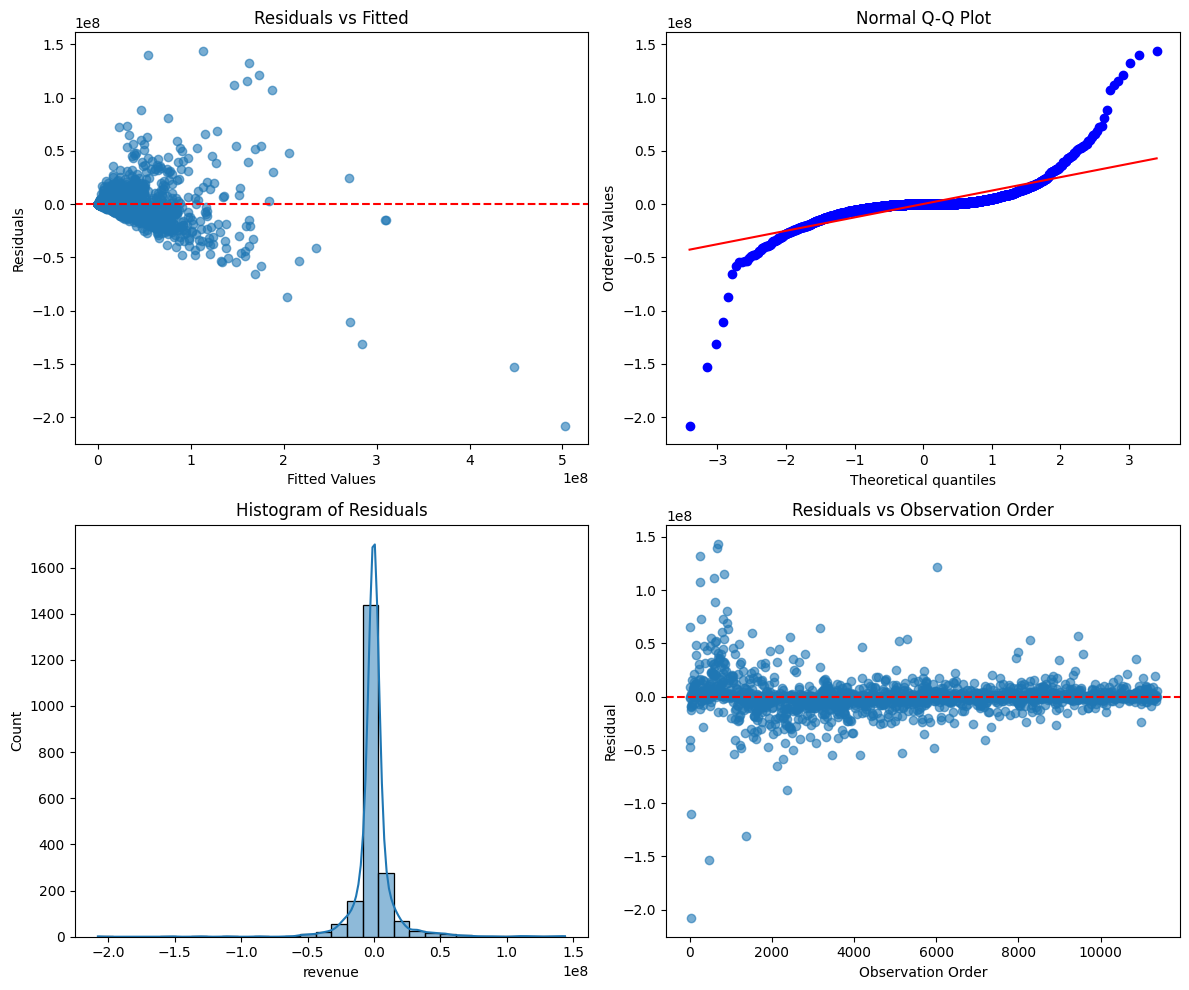

In [71]:
plot_residual_diagnostics(y_test, y_pred)

In [43]:
residuals, under, over = error_analysis(y_test, y_pred, X_test)

Top 5 Underestimations:


,trailer_views_log,trailer_likes_log,budget_log,budget_actor_interaction,trailer_star_interaction,is_holiday_release,production_popular,true_revenue,pred_revenue,residual,pct_error
265,13.932160,15.532106,16.593498,11.501736,71.371888,0,0,294.717694,26.664342,268.053352,0.909526
261,13.767791,15.386199,18.385258,0.000000,0.000000,1,0,294.717694,30.330023,264.387671,0.897088
26,15.292283,15.640783,15.739377,0.000000,0.000000,0,0,294.717694,44.331930,250.385764,0.849578
828,16.306672,15.964372,17.040649,27.425867,86.178276,0,0,275.675739,45.944457,229.731282,0.833339
685,16.415699,15.337389,16.748504,0.000000,0.000000,0,0,257.149638,40.519943,216.629695,0.842427



Top 5 Overestimations:


,trailer_views_log,trailer_likes_log,budget_log,budget_actor_interaction,trailer_star_interaction,is_holiday_release,production_popular,true_revenue,pred_revenue,residual,pct_error
8156,15.871012,17.055275,19.202819,0.000000,0.000000,0,1,72.816065,204.441590,-131.625526,-1.807644
5705,16.915694,17.081515,18.915092,0.000000,0.000000,1,0,83.208532,200.031135,-116.822603,-1.403974
6320,16.735714,17.466469,19.649061,13.619691,79.723046,1,1,139.511031,254.796756,-115.285725,-0.826356
7193,17.210068,17.168933,19.124817,13.256313,90.175929,0,1,96.881352,202.782713,-105.901361,-1.093104
5173,16.821183,16.958638,16.235286,0.000000,0.000000,0,0,79.229208,169.293097,-90.063889,-1.136751


In [26]:
over.index[0]

np.int64(8387)

In [27]:
df_clean.loc[over.index[0]]

Unnamed: 0                                                           9256
name                                                        Black Panther
genres                                            Action,Adventure,Sci-Fi
directors                                                    Ryan Coogler
writers                  Ryan Coogler,Joe Robert Cole,Stan Lee,Jack Kirby
averageRating                                                         7.3
numVotes                                                         867949.0
actors                  Pietro Dellanova,Peter Lurie,David Busch,Angel...
original_language                                                      en
production_companies                                       Marvel Studios
release_date                                                   2018-02-13
budget                                                   249844886.841068
revenue                                                   168636064.72547
runtime                               

In [15]:
df_clean['keyword_embedding'].describe()

count    10487.000000
mean        -0.002297
std          0.564115
min         -1.267071
25%         -0.205685
50%          0.174518
75%          0.406259
max          1.034193
Name: keyword_embedding, dtype: float64